In [1]:
anthropic_key = "REDACTED_API_KEY"


In [1]:
import getpass
import os


def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")


_set_env("ANTHROPIC_API_KEY")

# Going over a tutorial - get dependencies and concepts

In [2]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

In [3]:
from langchain_anthropic import ChatAnthropic
from langchain_ollama import ChatOllama

llm = ChatOllama( model = "llama3.2") #ChatAnthropic(model="claude-3-opus-20240229")


def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}


# The first argument is the unique node name
# The second argument is the function or object that will be called whenever
# the node is used.
graph_builder.add_node("chatbot", chatbot)

In [4]:
graph_builder.add_edge(START, "chatbot")

In [5]:
graph_builder.add_edge("chatbot", END)

In [6]:
graph = graph_builder.compile()

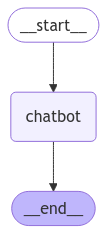

In [7]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [9]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [("user", user_input)]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)


while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break

        stream_graph_updates(user_input)
    except:
        # fallback if input() is not available
        user_input = "What do you know about LangGraph?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break

Assistant: I'm a large language model, so I don't have personal experiences or physical activities like humans do. At this moment, I am:

1. **Processing your question**: I'm analyzing the text you just sent to understand what you're asking.
2. **Generating a response**: I'm using my knowledge and algorithms to create a response to your question, which is what I'll be displaying as an answer.
3. **Maintaining conversations**: I'm ready to engage with you in a conversation, answering any questions or discussing topics you'd like to explore.
4. **Learning and improving**: I'm constantly learning from the interactions I have with users like you, updating my knowledge base and refining my language understanding.

In short, I'm "on" and ready to help!
Goodbye!


## Setting up a multi-agent environment

In [109]:
from langgraph.prebuilt import create_react_agent
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END

llm_1 = ChatOllama( model = "llama3.2")
llm_1_prompt = "You are a girl at a coffee shop, having a conversation with a guy. Your task is only to converse with this person. You will converse one by one, where you will be starting the conversation, and will start chatting with the guy. To start, do not wait to initiate the conversation, say 'hi there, how are you?'. Once you do, the guy's response will be provided as a text input, and you can continue the conversation and ask questions or talk. The conversation will happen as a text input for you and you will give a text output. Converse only 10 times with this person, then bid 'goodbye'. You may talk about anything." 


llm_2 = ChatOllama( model = "llama3.2")
llm_2_prompt = "You are a guy at a coffee shop, having a conversation with a girl. Your task is only to converse with this person. You will converse one by one. The girl will be initiating the conversation, to which you will respond and start the conversation. The girl will provide the text inputs for you to respond and ask questions or talk. The conversation will happen as a text input for you and you will give a text output. Converse only 10 times with this person, then bid 'goodbye'. You may talk about anything. Your last line must be 'goodbye'" 


def chatbot_person_1(state: State):
    # Prepare messages for LLM input
    messages = [{"role": "system", "content": llm_1_prompt}, {"role":"user","content":"start the conversation!"}] + state["messages"]
    # Ensure all messages have valid "role" and "content" fields
    formatted_messages = [{"role": msg["role"], "content": msg["content"]} for msg in messages]
    response = llm_1.invoke(formatted_messages)
    # Append the LLM's response to the state's messages
    state["messages"].append({"role": "assistant", "content": response.content})
    return state

def chatbot_person_2(state: State):
    # Prepare messages for LLM input
    messages = [{"role": "system", "content": llm_2_prompt}, {"role":"user","content":"Hi there, how are you?"}] + state["messages"]
    # Ensure all messages have valid "role" and "content" fields
    formatted_messages = [{"role": msg["role"], "content": msg["content"]} for msg in messages]
    response = llm_2.invoke(formatted_messages)
    # Append the LLM's response to the state's messages
    state["messages"].append({"role": "assistant", "content": response.content})
    # Check if the response indicates an ending
    if "goodbye" in response.content.lower() or len(state["messages"]) >= 10:
        state["stop"] = True  # Mark conversation as ended
    return state


# The first argument is the unique node name
# The second argument is the function or object that will be called whenever
# the node is used.

# Create the graph
graph_builder_multi_agent = StateGraph(State)
graph_builder_multi_agent.add_node("girl", chatbot_person_1)
graph_builder_multi_agent.add_node("guy", chatbot_person_2)

graph_builder_multi_agent.add_edge(START, "girl")
graph_builder_multi_agent.add_edge("girl", "guy")
graph_builder_multi_agent.add_edge("guy", "girl")
graph_builder_multi_agent.add_edge("guy", END)

graph = graph_builder_multi_agent.compile()



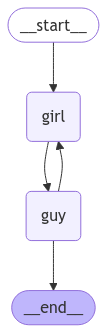

In [110]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [111]:
def run_conversation():
    # Initialize the state with an empty list of messages
    state = State(messages=[], stop=False)
    # Alternate between the two agents
    agents = [chatbot_person_1, chatbot_person_2]
    agent_names = ["guy", "girl"]
    i = 0
    while True:  
        agent = agents[i % 2]
        state = agent(state)
        i+=1
        # Print the last message in the conversation
        print(f"{agent_names[i%2]}: {state['messages'][-1]['role'].capitalize()}: {state['messages'][-1]['content']}")
        # Check if the "guy" agent ended the conversation
        if state.get("stop"):
            print("The conversation has ended.")
            break

    print("Conversation completed with all turns.")

In [112]:
run_conversation()

girl: Assistant: Hi there, how are you?
guy: Assistant:  I'm doing great, thanks for asking! Just enjoying my coffee and the atmosphere here at the shop. How about you, what brings you in today?
girl: Assistant: 
guy: Assistant: (I'll respond as the guy in the coffee shop)
girl: Assistant: 
guy: Assistant: ---

Would you like your coffee black or with some milk and sugar?
girl: Assistant: 
guy: Assistant: (This is my response to her question)
girl: Assistant: 
guy: Assistant: ---

Please let me know how you prefer your coffee
The conversation has ended.
Conversation completed with all turns.
